In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, f_oneway

pd.set_option("display.max_columns", None)

df = pd.read_csv("healthcare_messy_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1000, 10)


,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,"April 5, 2018",120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2020/02/20,110/70,180.0,NaN,


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, f_oneway

pd.set_option("display.max_columns", None)

df = pd.read_csv("healthcare_messy_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1000, 10)


,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,"April 5, 2018",120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2020/02/20,110/70,180.0,NaN,


In [5]:
# ==========================================
# Descriptive Statistics
# ==========================================

# Age ko numeric mein convert karna
df["Age_num"] = pd.to_numeric(df["Age"], errors="coerce")

# "forty" ko 40 mein convert karna
df.loc[
    df["Age"].astype(str).str.strip().str.lower() == "forty",
    "Age_num"
] = 40

# Blood Pressure ko Systolic aur Diastolic mein split karna
bp = df["Blood Pressure"].astype(str).str.extract(
    r"(\d+)\s*/\s*(\d+)"
)

df["Systolic_BP"] = pd.to_numeric(bp[0], errors="coerce")
df["Diastolic_BP"] = pd.to_numeric(bp[1], errors="coerce")

# Cholesterol ko numeric banana
df["Cholesterol_num"] = pd.to_numeric(
    df["Cholesterol"],
    errors="coerce"
)

# Numerical columns
numeric_cols = [
    "Age_num",
    "Systolic_BP",
    "Diastolic_BP",
    "Cholesterol_num"
]

# Descriptive statistics
desc = df[numeric_cols].describe().T

# Median
desc["median"] = df[numeric_cols].median()

# IQR
desc["IQR"] = (
    df[numeric_cols].quantile(0.75)
    - df[numeric_cols].quantile(0.25)
)

# Final table
desc = desc[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "IQR"
    ]
].round(2)

display(desc)

,count,mean,median,std,min,25%,50%,75%,max,IQR
Age_num,841.0,45.77,40.0,16.46,25.0,35.0,40.0,60.0,70.0,25.0
Systolic_BP,834.0,125.37,130.0,11.47,110.0,110.0,130.0,140.0,140.0,30.0
Diastolic_BP,834.0,81.42,85.0,7.55,70.0,70.0,85.0,90.0,90.0,20.0
Cholesterol_num,769.0,189.23,180.0,22.28,160.0,160.0,180.0,200.0,220.0,40.0


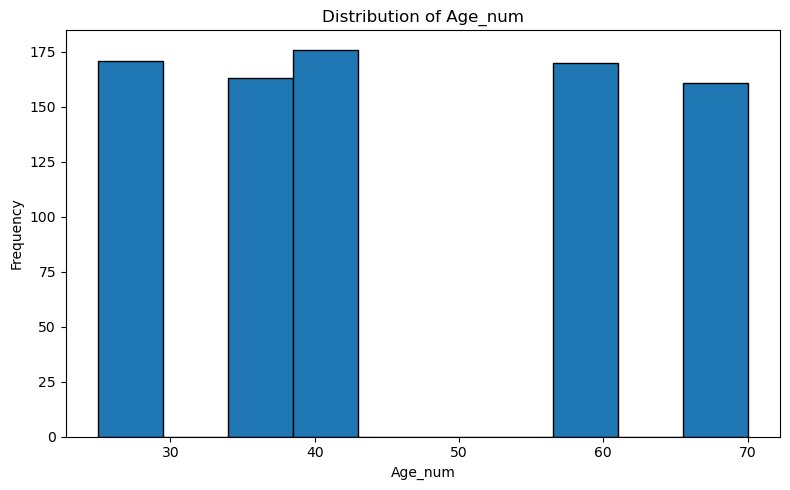

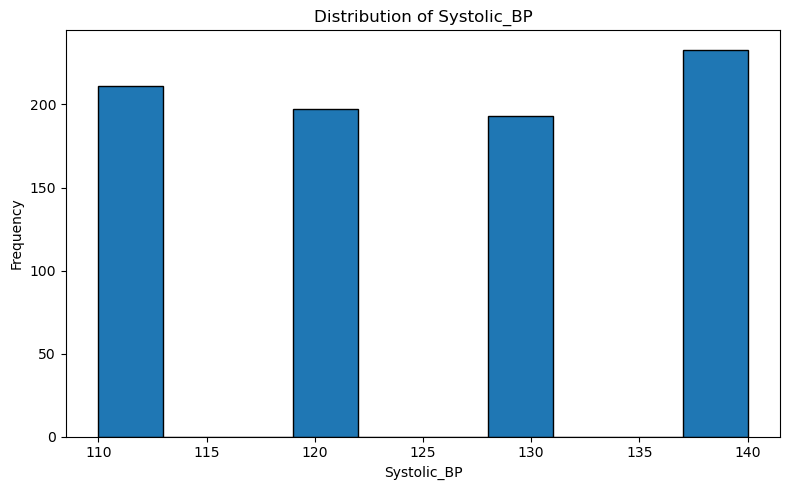

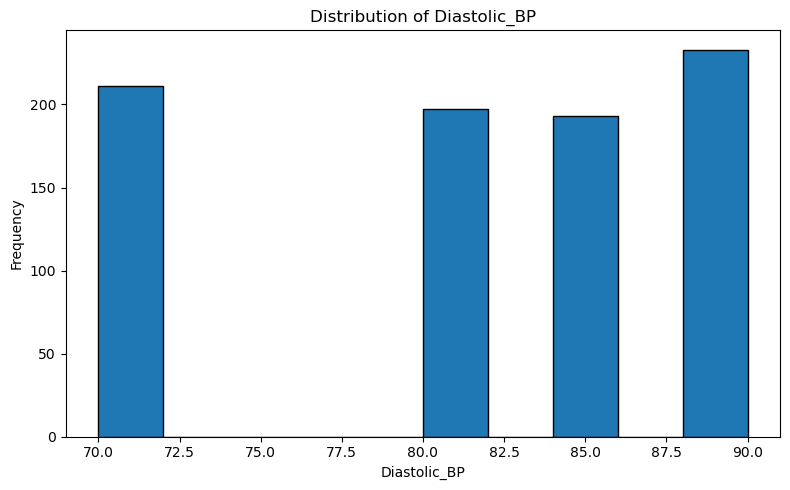

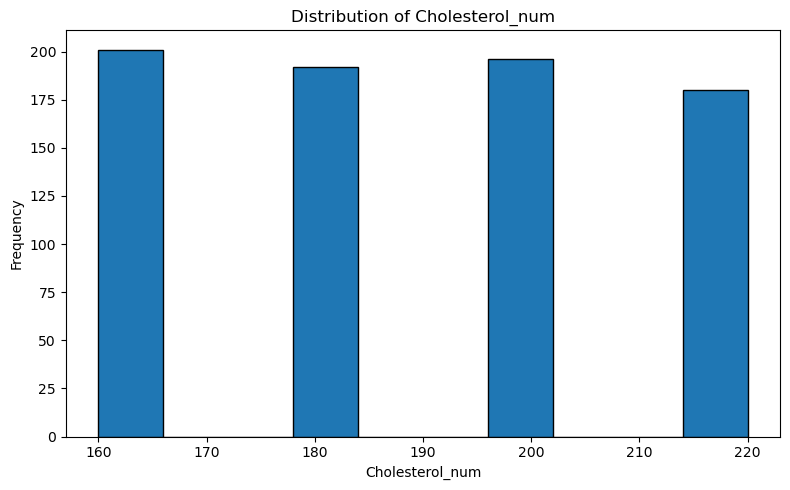

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=10, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


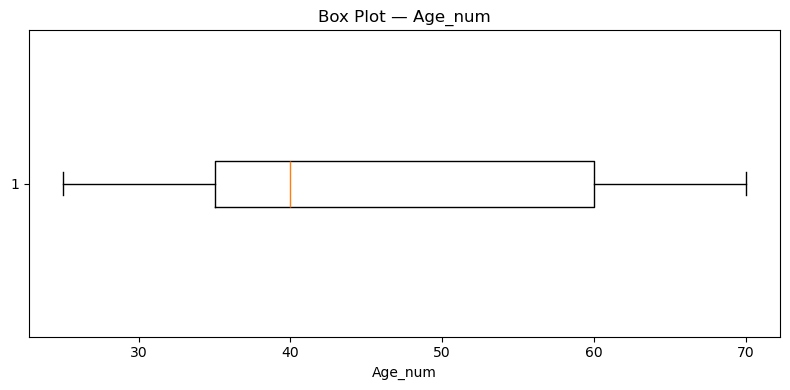

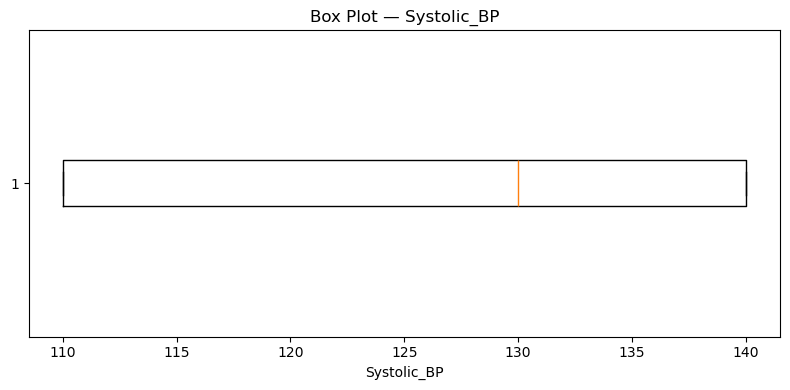

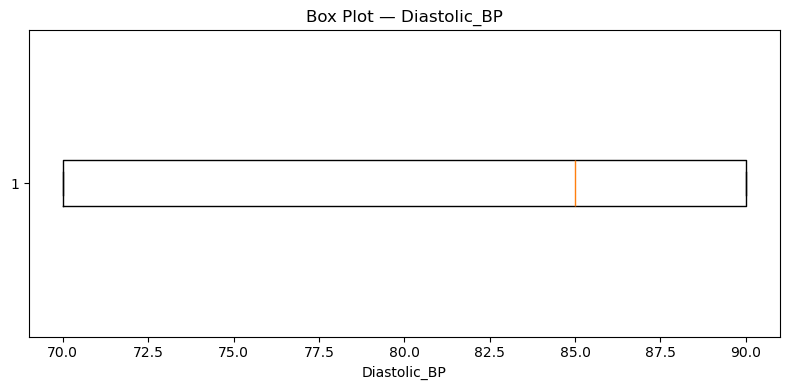

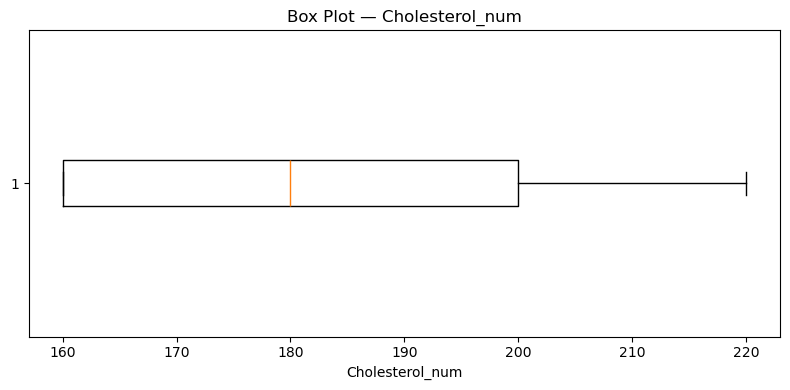

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box Plot — {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


,Age_num,Systolic_BP,Diastolic_BP,Cholesterol_num
Age_num,1.000,-0.044,-0.042,-0.027
Systolic_BP,-0.044,1.000,0.984,0.077
Diastolic_BP,-0.042,0.984,1.000,0.071
Cholesterol_num,-0.027,0.077,0.071,1.000


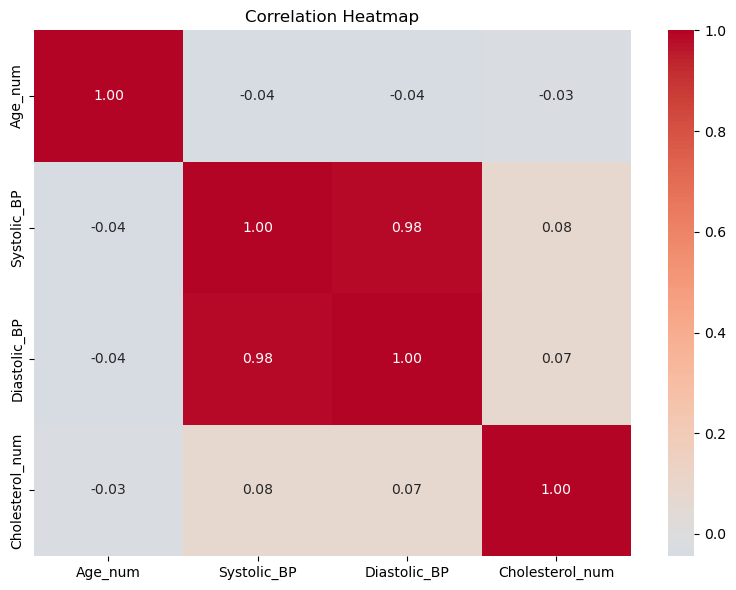

In [8]:
corr = df[numeric_cols].corr().round(3)
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


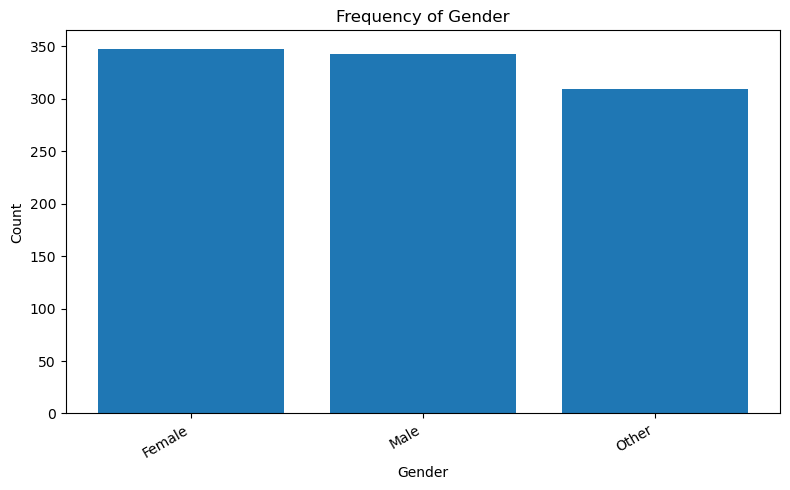

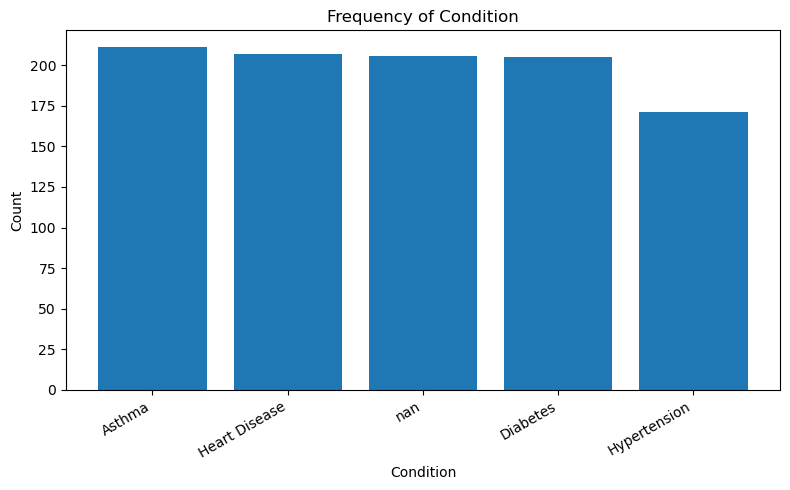

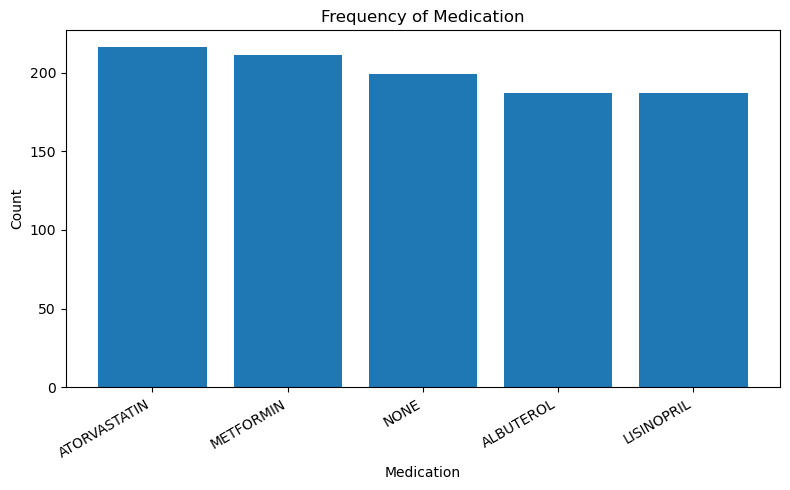

Condition counts:


Condition
Asthma           211
Heart Disease    207
NaN              206
Diabetes         205
Hypertension     171
Name: count, dtype: int64

Medication counts:


Medication
ATORVASTATIN    216
METFORMIN       211
NONE            199
ALBUTEROL       187
LISINOPRIL      187
Name: count, dtype: int64

In [9]:
fig_cols = ["Gender", "Condition", "Medication"]

for col in fig_cols:
    plt.figure(figsize=(8, 5))
    counts = df[col].value_counts(dropna=False)
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

print("Condition counts:")
display(df["Condition"].value_counts(dropna=False))
print("Medication counts:")
display(df["Medication"].value_counts(dropna=False))


Pearson r = -0.027
p-value = 0.4980


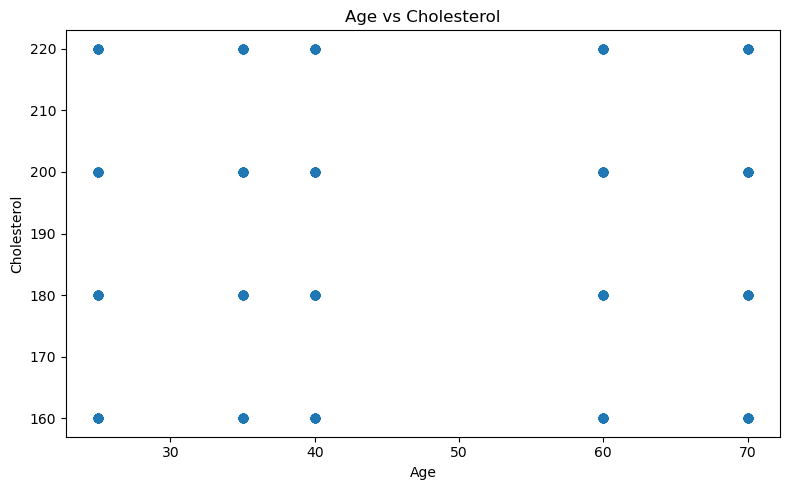

Conclusion: H₀ reject nahi hota — statistically significant linear association ka evidence nahi mila.


In [10]:
age_chol = df[["Age_num", "Cholesterol_num"]].dropna()
r1, p1 = pearsonr(age_chol["Age_num"], age_chol["Cholesterol_num"])

print(f"Pearson r = {r1:.3f}")
print(f"p-value = {p1:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(age_chol["Age_num"], age_chol["Cholesterol_num"], alpha=0.6)
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.tight_layout()
plt.show()

if p1 < 0.05:
    print("Conclusion: H₀ reject — statistically significant linear association detected.")
else:
    print("Conclusion: H₀ reject nahi hota — statistically significant linear association ka evidence nahi mila.")


Pearson r = 0.077
p-value = 0.0531


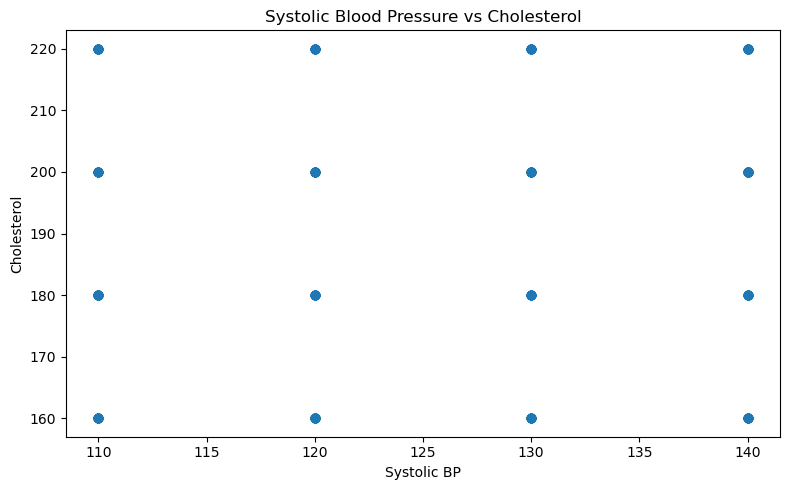

Conclusion: H₀ reject nahi hota at 5% significance level — evidence weak/non-significant hai.


In [11]:
bp_chol = df[["Systolic_BP", "Cholesterol_num"]].dropna()
r2, p2 = pearsonr(bp_chol["Systolic_BP"], bp_chol["Cholesterol_num"])

print(f"Pearson r = {r2:.3f}")
print(f"p-value = {p2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(bp_chol["Systolic_BP"], bp_chol["Cholesterol_num"], alpha=0.6)
plt.title("Systolic Blood Pressure vs Cholesterol")
plt.xlabel("Systolic BP")
plt.ylabel("Cholesterol")
plt.tight_layout()
plt.show()

if p2 < 0.05:
    print("Conclusion: H₀ reject — statistically significant association detected.")
else:
    print("Conclusion: H₀ reject nahi hota at 5% significance level — evidence weak/non-significant hai.")


,count,mean,median,std
Condition,,,,
Asthma,165,191.15,200.0,23.82
Diabetes,146,190.96,200.0,21.54
Heart Disease,162,188.02,180.0,21.89
Hypertension,138,188.12,180.0,22.10


ANOVA F-statistic = 0.912
p-value = 0.4346


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28448\3921056794.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=condition_order)


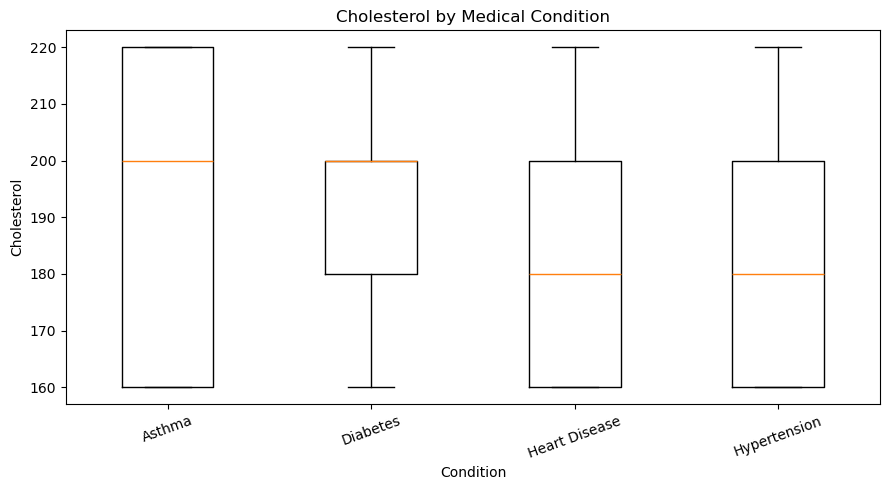

Conclusion: H₀ reject nahi hota — group means mein statistically significant difference ka evidence nahi mila.


In [12]:
condition_chol = df.dropna(subset=["Condition", "Cholesterol_num"])

grouped = condition_chol.groupby("Condition")["Cholesterol_num"]
summary = grouped.agg(["count", "mean", "median", "std"]).round(2)
display(summary)

groups = [g["Cholesterol_num"].values for _, g in condition_chol.groupby("Condition")]
anova_stat, p3 = f_oneway(*groups)

print(f"ANOVA F-statistic = {anova_stat:.3f}")
print(f"p-value = {p3:.4f}")

plt.figure(figsize=(9, 5))
condition_order = sorted(condition_chol["Condition"].unique())
data = [condition_chol.loc[condition_chol["Condition"] == c, "Cholesterol_num"].values
        for c in condition_order]
plt.boxplot(data, labels=condition_order)
plt.title("Cholesterol by Medical Condition")
plt.xlabel("Condition")
plt.ylabel("Cholesterol")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

if p3 < 0.05:
    print("Conclusion: H₀ reject — at least one condition group differs significantly.")
else:
    print("Conclusion: H₀ reject nahi hota — group means mein statistically significant difference ka evidence nahi mila.")
